# Coding Task: Overfitting, Regularization, and Validation

**Goal:** Understand overfitting, how to detect it, and how regularization and cross‑validation help prevent it.

## Background

We will generate a dataset from a noisy sine function:  
\[
y = \sin(2\pi x) + \epsilon,\quad \epsilon \sim \mathcal{N}(0, \sigma^2)
\]
with a small amount of noise (\(\sigma = 0.2\)). We will use **polynomial regression** of varying degrees to see the effect of model complexity.

You will:
- Fit polynomial models from degree 1 to 15.
- Observe how training error decreases while test error eventually increases (overfitting).
- Use **5‑fold cross‑validation** to choose the optimal polynomial degree.
- Apply **ridge regression** (L2 regularization) to a high‑degree polynomial and compare the regularised model with the unregularised one.
- Answer questions about the bias‑variance tradeoff and the role of regularization.

## What You Will Do

1. Generate synthetic data (training, validation, test sets).
2. Train polynomial regression models for degrees 1–15 on the training set.
3. Plot training and test errors vs. degree – identify overfitting.
4. Use **cross‑validation** (on the training set only) to select the best degree.
5. Train a high‑degree polynomial (e.g., degree 15) with ridge regression and vary the regularization strength \(\lambda\).
6. Plot the effect of \(\lambda\) on training and test errors.
7. Answer the questions.

## Questions to Answer

1. At what polynomial degree does overfitting become visible? How can you tell?
2. What is the optimal degree according to cross‑validation? Does it match the test error minimum?
3. For a fixed high degree (e.g., 15), how does increasing the regularization strength \(\lambda\) affect training and test errors? Why?
4. What is the relationship between model complexity, bias, and variance? Explain using your plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

def generate_data(n_samples, noise_std=0.2, x_range=(0,1)):
    x = np.random.uniform(x_range[0], x_range[1], n_samples)
    x_sorted = np.sort(x)
    y = np.sin(2 * np.pi * x_sorted) + np.random.normal(0, noise_std, n_samples)
    return x_sorted, y

# Generate a large dataset (500 points)
X_all, y_all = generate_data(500, noise_std=0.2)

# Split into training (60%), validation (20%), and test (20%)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 300 samples
Validation set: 100 samples
Test set: 100 samples


In [3]:
def fit_polynomial(degree, X_train, y_train, X_test, y_test):
    """
    Fit a polynomial of given degree to the training data.
    Returns: train_error, test_error (MSE)
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
    X_test_poly = poly.transform(X_test.reshape(-1, 1))
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    return train_mse, test_mse

In [5]:
degrees = range(1, 16)
train_errors = []
test_errors = []

for d in degrees:
    train_err, test_err = fit_polynomial(d, X_train, y_train, X_test, y_test)
    train_errors.append(train_err)
    test_errors.append(test_err)
    print(f"Degree {d:2d}: Train MSE = {train_err:.6f}, Test MSE = {test_err:.6f}")

Degree  1: Train MSE = 0.228128, Test MSE = 0.246756
Degree  2: Train MSE = 0.227783, Test MSE = 0.242657
Degree  3: Train MSE = 0.042177, Test MSE = 0.046455
Degree  4: Train MSE = 0.042054, Test MSE = 0.046500
Degree  5: Train MSE = 0.038263, Test MSE = 0.045636
Degree  6: Train MSE = 0.038164, Test MSE = 0.045984
Degree  7: Train MSE = 0.037701, Test MSE = 0.046716
Degree  8: Train MSE = 0.037672, Test MSE = 0.045966
Degree  9: Train MSE = 0.037548, Test MSE = 0.046628
Degree 10: Train MSE = 0.037487, Test MSE = 0.047128
Degree 11: Train MSE = 0.037310, Test MSE = 0.047142
Degree 12: Train MSE = 0.037310, Test MSE = 0.047135
Degree 13: Train MSE = 0.037210, Test MSE = 0.047074
Degree 14: Train MSE = 0.036362, Test MSE = 0.047634
Degree 15: Train MSE = 0.036341, Test MSE = 0.048088


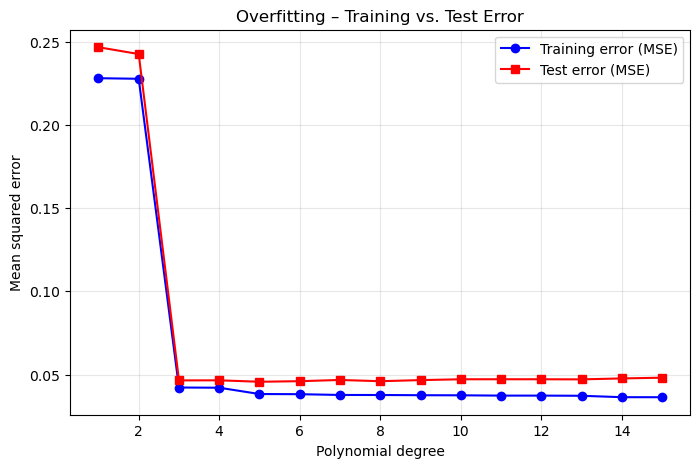

In [7]:
plt.figure(figsize=(8,5))
plt.plot(degrees, train_errors, 'bo-', label='Training error (MSE)')
plt.plot(degrees, test_errors, 'rs-', label='Test error (MSE)')
plt.xlabel('Polynomial degree')
plt.ylabel('Mean squared error')
plt.title('Overfitting – Training vs. Test Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
def cross_val_poly_degree(degree, X, y, cv=5):
    """
    Perform 5-fold cross-validation on the training set (X, y) for a given polynomial degree.
    Returns: average validation MSE.
    """
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X.reshape(-1, 1))
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=cv, scoring='neg_mean_squared_error')
    return -scores.mean()  # positive MSE

# Use only the training set (X_train, y_train) for cross-validation
cv_errors = []
for d in degrees:
    cv_err = cross_val_poly_degree(d, X_train, y_train, cv=5)
    cv_errors.append(cv_err)
    print(f"Degree {d:2d}: CV MSE = {cv_err:.6f}")

best_degree = degrees[np.argmin(cv_errors)]
print(f"\nBest degree according to cross-validation: {best_degree}")

Degree  1: CV MSE = 0.235245
Degree  2: CV MSE = 0.238455
Degree  3: CV MSE = 0.042810
Degree  4: CV MSE = 0.043414
Degree  5: CV MSE = 0.039816
Degree  6: CV MSE = 0.040911
Degree  7: CV MSE = 0.042027
Degree  8: CV MSE = 0.043073
Degree  9: CV MSE = 0.043628
Degree 10: CV MSE = 0.044208
Degree 11: CV MSE = 0.044456
Degree 12: CV MSE = 0.044749
Degree 13: CV MSE = 0.044561
Degree 14: CV MSE = 0.042876
Degree 15: CV MSE = 0.043567

Best degree according to cross-validation: 5


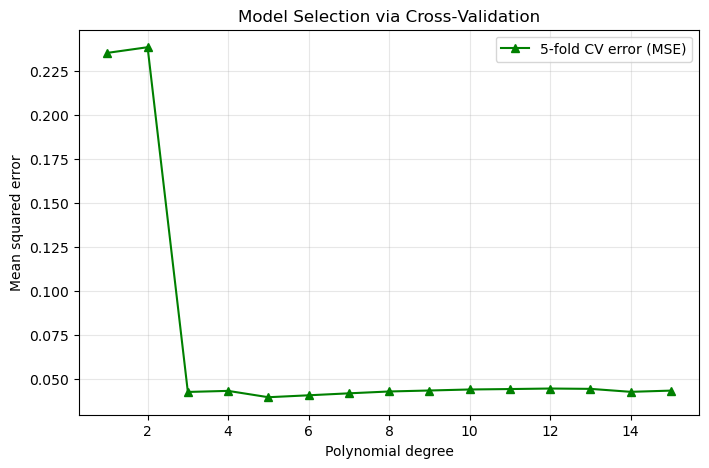

In [11]:
plt.figure(figsize=(8,5))
plt.plot(degrees, cv_errors, 'g^-', label='5‑fold CV error (MSE)')
plt.xlabel('Polynomial degree')
plt.ylabel('Mean squared error')
plt.title('Model Selection via Cross‑Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
def fit_ridge(degree, alpha, X_train, y_train, X_test, y_test):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
    X_test_poly = poly.transform(X_test.reshape(-1, 1))
    
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    
    train_mse = mean_squared_error(y_train, model.predict(X_train_poly))
    test_mse = mean_squared_error(y_test, model.predict(X_test_poly))
    return train_mse, test_mse

# Vary alpha (regularisation strength)
alphas = [1e-6, 1e-4, 1e-2, 1e-1, 1, 10, 100, 1000]
ridge_train_err = []
ridge_test_err = []

for alpha in alphas:
    tr, te = fit_ridge(15, alpha, X_train, y_train, X_test, y_test)
    ridge_train_err.append(tr)
    ridge_test_err.append(te)
    print(f"alpha = {alpha:8.4f}: Train MSE = {tr:.6f}, Test MSE = {te:.6f}")

alpha =   0.0000: Train MSE = 0.037726, Test MSE = 0.045396
alpha =   0.0001: Train MSE = 0.037865, Test MSE = 0.044700
alpha =   0.0100: Train MSE = 0.041754, Test MSE = 0.049881
alpha =   0.1000: Train MSE = 0.062012, Test MSE = 0.063905
alpha =   1.0000: Train MSE = 0.114473, Test MSE = 0.104446
alpha =  10.0000: Train MSE = 0.163944, Test MSE = 0.147755
alpha = 100.0000: Train MSE = 0.333096, Test MSE = 0.324279
alpha = 1000.0000: Train MSE = 0.471265, Test MSE = 0.449760


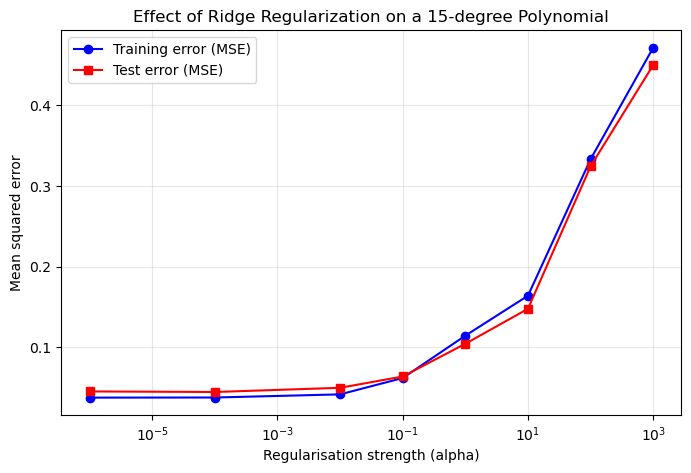

In [15]:
plt.figure(figsize=(8,5))
plt.semilogx(alphas, ridge_train_err, 'bo-', label='Training error (MSE)')
plt.semilogx(alphas, ridge_test_err, 'rs-', label='Test error (MSE)')
plt.xlabel('Regularisation strength (alpha)')
plt.ylabel('Mean squared error')
plt.title('Effect of Ridge Regularization on a 15‑degree Polynomial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

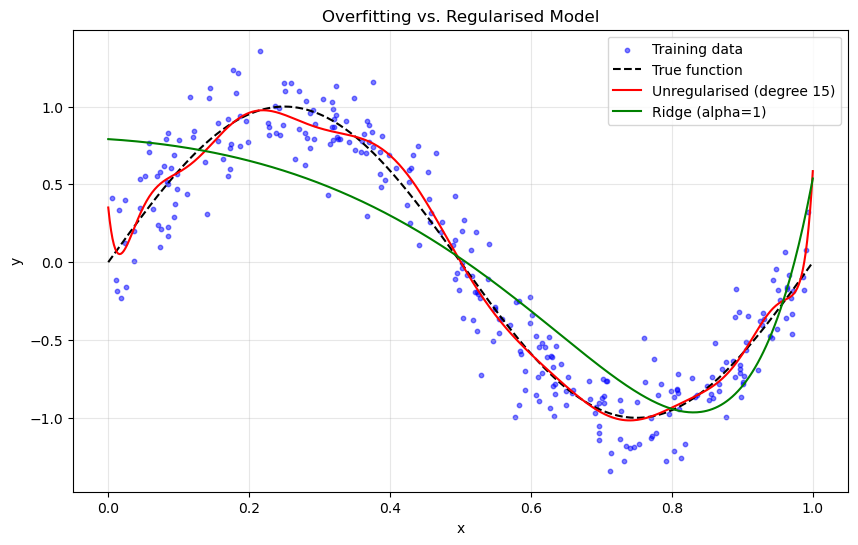

In [17]:
# Fit unregularised (degree 15)
poly = PolynomialFeatures(degree=15, include_bias=False)
X_train_poly = poly.fit_transform(X_train.reshape(-1, 1))
X_test_poly = poly.transform(X_test.reshape(-1, 1))
unreg_model = LinearRegression()
unreg_model.fit(X_train_poly, y_train)

# Fit ridge (alpha=1)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_poly, y_train)

# Generate smooth x for plotting
x_plot = np.linspace(0, 1, 500)
X_plot_poly = poly.transform(x_plot.reshape(-1, 1))

y_true = np.sin(2 * np.pi * x_plot)
y_unreg = unreg_model.predict(X_plot_poly)
y_ridge = ridge_model.predict(X_plot_poly)

plt.figure(figsize=(10,6))
plt.scatter(X_train, y_train, c='blue', s=10, alpha=0.5, label='Training data')
plt.plot(x_plot, y_true, 'k--', label='True function')
plt.plot(x_plot, y_unreg, 'r-', label='Unregularised (degree 15)')
plt.plot(x_plot, y_ridge, 'g-', label='Ridge (alpha=1)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Overfitting vs. Regularised Model')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Questions to Answer

Write your answers below (double‑click to edit this cell).

1. **At what polynomial degree does overfitting become visible? How can you tell?**  
   (Look at the first plot – training error keeps decreasing, but test error starts to increase. Which degree does that happen at?)

2. **What is the optimal degree according to cross‑validation? Does it match the test error minimum?**  
   (Compare the CV plot with the test error from the first plot. Are they consistent?)

3. **For a fixed high degree (e.g., 15), how does increasing the regularization strength \(\lambda\) affect training and test errors? Why?**  
   (Look at the ridge plot. At very small \(\lambda\), the model overfits. As \(\lambda\) increases, test error first decreases (less overfitting), then eventually increases (underfitting). Explain.)

4. **What is the relationship between model complexity, bias, and variance?**  
   (Use the bias‑variance decomposition: low complexity = high bias, low variance; high complexity = low bias, high variance. Regularisation increases bias but reduces variance.)

5. **In the final visual comparison, how does the regularised curve differ from the unregularised one? Which one generalises better?**  
   (The unregularised curve oscillates wildly; the regularised curve is smoother and closer to the true sine function.)